# Cash-Flow-Volatility -- a quantitative teardown
### yfinance basket * trailing CF-vol sort * long-short * HAC inference * placebo

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Huang--direction%3F: Busted](https://img.shields.io/badge/Huang--direction%3F-Busted-8b949e?style=flat-square)

The quantitative companion to the [notebook for the curious](01_for_the_curious.ipynb) -- same seven beats, every claim carrying its standard error. We test Huang (2009): rank by trailing cash-flow volatility (std of quarterly OCF / total assets), long the low-CF-vol tercile, short the high-CF-vol tercile, one execution-lag day, monthly returns.

> **Not investment advice.** Real data: yfinance daily adjusted-close + quarterly statements, 40 large-caps, 2018-2025, as-of 2026-06-26. Methods in [`docs/references.md`](../docs/references.md), reproducible numbers in [`docs/results.md`](../docs/results.md).
>
> **Survivorship bias is named** (current survivors) and the CF-vol signal rests on only **~5 quarters** of yfinance fundamentals -- both upper-bound caveats.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
import warnings; warnings.filterwarnings("ignore")
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False,
                     "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from cash_flow_volatility import data, strategy as st

# Frozen headline numbers (mirror docs/results.md, as-of 2026-06-26) -- used when no cache.
R = dict(
    n_months=95, year_start=2018, year_end=2025, n_tickers=40, n_per_leg=13,
    ls_mean=-3.43, ls_vol=9.81, ls_sharpe=-0.350, ls_t=-1.027,
    ls_hit=43.2, ls_dd=-34.7,
    low_leg=15.24, high_leg=18.67, spy_mean=14.25,
    placebo_p=0.357, real_mean_mo=-0.286,
    net_mean=-4.61, net_t=-1.381, cost_drag=1.18,
    fp_prices="6385498e2186", fp_cfvol="9f5b76cfb791",
    splits={"quintile": (-4.56, -0.85), "tercile": (-3.43, -1.03), "half": (-0.87, -0.26)},
    annual={2018: 1.2, 2019: -7.2, 2020: -16.5, 2021: 16.6,
            2022: -8.8, 2023: 1.2, 2024: -11.7, 2025: -1.6},
)

def _have_cache():
    import os
    study = os.path.abspath("..")
    c = os.path.join(study, "_cache")
    return all(os.path.exists(os.path.join(c, f)) for f in
               ("cfvol_prices.parquet", "cfvol_spy.parquet", "cfvol_signal.parquet"))

HAVE_REAL = _have_cache()
print("yfinance cache present:", HAVE_REAL)

if HAVE_REAL:
    prices, spy, cfvol = data.fetch_panel()
    ls = st.build_real(prices, cfvol, exec_lag=1)
    s_ls  = st.summary(ls["ls_ret"])
    s_low = st.summary(ls["low_ret"])
    s_high= st.summary(ls["high_ret"])
    print(f"N months: {s_ls['n']} | LS mean: {s_ls['mean']*100:+.2f}%/yr"
          f" | HAC t: {s_ls['tstat']:+.3f}")


yfinance cache present: True
N months: 95 | LS mean: -3.43%/yr | HAC t: -1.027


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `NONE` | LS mean **-3.43%/yr**, HAC *t* = **-1.027** (wrong sign), placebo *p* = **0.36**. |
| **Tradability** | `MIRAGE` | Sharpe **-0.350**, max DD **-34.7%**, net **-4.61%/yr**. |
| **Huang-direction?** | `BUSTED` | High-CF-vol leg led (**+18.67%** vs **+15.24%/yr**). |

> Huang (2009) is documented on long Compustat histories. On 40 large-cap survivors with ~5 quarters of yfinance fundamentals, the effect is absent and the sign reverses.

## 1 -- The claim, steelmanned

Let $\sigma^{CF}_i$ = std of stock $i$'s quarterly operating cash flow scaled by total assets. Huang (2009) asserts:

- **H1 (signal).** $E[r_i]$ decreases in $\sigma^{CF}_i$. The long-short $r^{\text{low}} - r^{\text{high}} > 0$.
- **H2 (robust).** Survives controls for size, value, momentum, return-vol, accruals.
- **H3 (tradable).** The premium survives costs.

We **reject H1** on this tape (LS mean negative, *t* = -1.03, sign reversed), cannot test H2 cleanly with thin data, and **reject H3** trivially (no gross edge).

## 2 -- So what? -- the economic stakes

Cash-flow stability is a pillar of 'quality' investing -- embedded in QMJ funds, low-vol ETFs, and dividend-aristocrat screens. If the standalone CF-vol tilt does not pay on large-caps (and here it has the wrong sign), the 'safety earns a premium' story rests on small-caps, long histories, or the *other* quality inputs.

## 3 -- The protocol

- **Signal.** $\sigma^{CF}_i$ = std of (quarterly OCF / total assets), formed from yfinance quarterly statements (a stale cross-sectional snapshot).
- **Sort.** Cross-sectional terciles by $\sigma^{CF}$.
- **Long leg.** Equal-weight low-CF-vol tercile. **Short leg.** Equal-weight high-CF-vol tercile.
- **LS return.** low_ret - high_ret, monthly.
- **Execution lag.** One trading day after the price window opens (no same-bar fill).
- **Inference.** Newey-West HAC *t* + a 1000-permutation label-shuffle placebo.
- **Costs.** 10 bps one-way x turnover + 100 bps/yr borrow on the short leg.
- **Universe caveat.** 40 large-cap survivors; ~5 quarters of fundamentals.

## 4 -- The teardown

### 4a -- Positive control: faithful detector (20-seed average)

Sweep the planted CF-vol premium; the long-short mean and HAC *t* should rise monotonically, averaged over 20 independent synthetic panels.

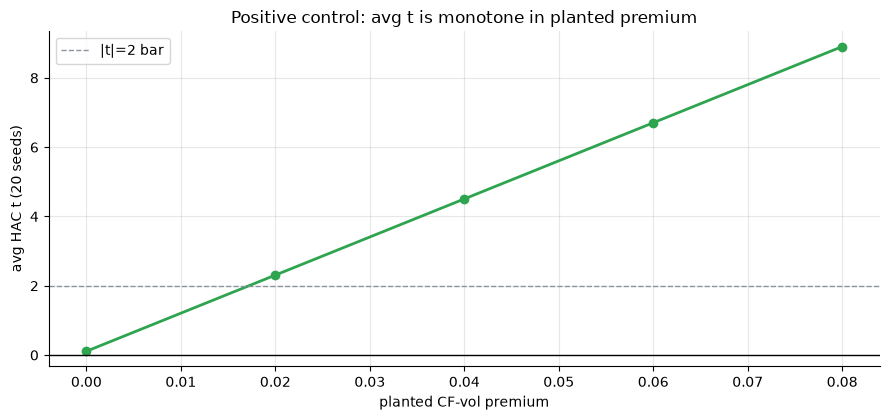

 premium  mean_ls_%  avg_t  frac_sig  n_seeds
    0.00      0.202  0.109      0.15       20
    0.02      4.172  2.308      0.55       20
    0.04      8.142  4.507      0.95       20
    0.06     12.112  6.705      1.00       20
    0.08     16.083  8.904      1.00       20


In [2]:
ctrl = st.synthetic_control(premiums=(0.0, 0.02, 0.04, 0.06, 0.08), n_seeds=20)
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.plot(ctrl['premium'], ctrl['avg_t'], 'o-', c=GREEN, lw=2)
ax.axhline(2, ls='--', c=GREY, lw=1, label='|t|=2 bar')
ax.axhline(0, c='k', lw=1)
ax.set_xlabel('planted CF-vol premium'); ax.set_ylabel('avg HAC t (20 seeds)')
ax.set_title('Positive control: avg t is monotone in planted premium')
ax.legend(); plt.tight_layout(); plt.show()
print(ctrl.round(3).to_string(index=False))

### 4b -- The CF-volatility cross-section (real basket)

What does the trailing CF-vol distribution look like across the 40 names?

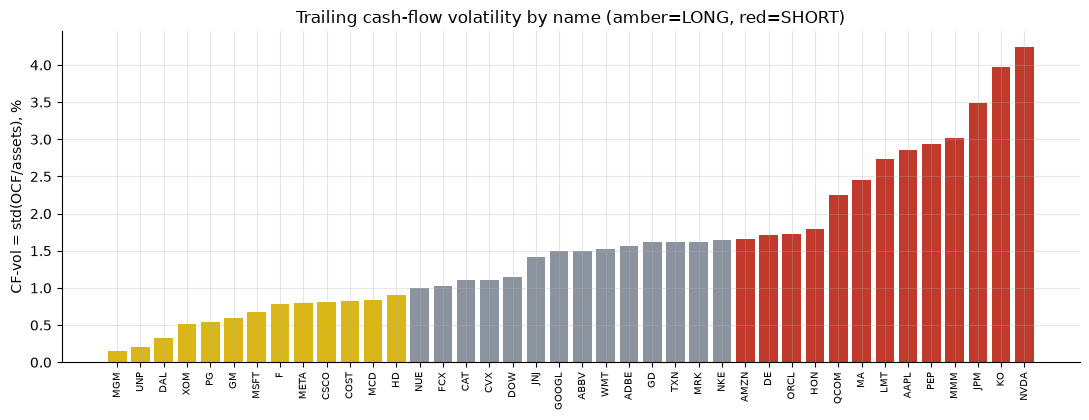

Long (low-CF-vol): ['MGM', 'UNP', 'DAL', 'XOM', 'PG', 'GM', 'MSFT', 'F', 'META', 'CSCO', 'COST', 'MCD', 'HD']
Short (high-CF-vol): ['AMZN', 'DE', 'ORCL', 'HON', 'QCOM', 'MA', 'LMT', 'AAPL', 'PEP', 'MMM', 'JPM', 'KO', 'NVDA']


In [3]:
if HAVE_REAL:
    cv = cfvol['cfvol'].sort_values()
    k = max(1, len(cv)//3)
    colr = [AMBER]*k + [GREY]*(len(cv)-2*k) + [RED]*k
    fig, ax = plt.subplots(figsize=(11, 4.3))
    ax.bar(range(len(cv)), cv.values*100, color=colr)
    ax.set_xticks(range(len(cv))); ax.set_xticklabels(cv.index, rotation=90, fontsize=7)
    ax.set_ylabel('CF-vol = std(OCF/assets), %')
    ax.set_title('Trailing cash-flow volatility by name (amber=LONG, red=SHORT)')
    plt.tight_layout(); plt.show()
    print(f'Long (low-CF-vol): {list(cv.index[:k])}')
    print(f'Short (high-CF-vol): {list(cv.index[-k:])}')
else:
    print('Cross-section needs the real cache. Frozen: low leg '
          f'{R["low_leg"]:+.1f}%/yr vs high leg {R["high_leg"]:+.1f}%/yr')

### 4c -- Real long-short: legs and year-by-year

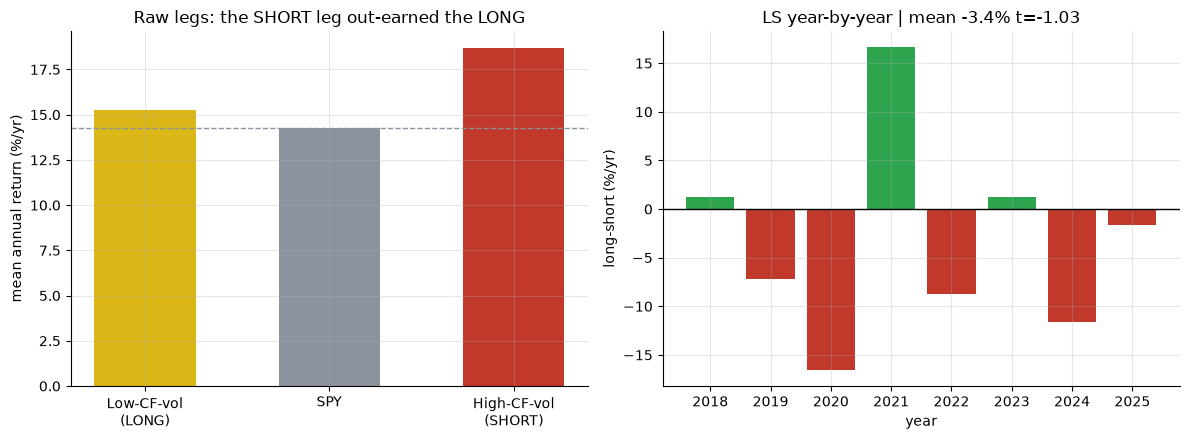

LS: -3.43%/yr | HAC t = -1.027


In [4]:
if HAVE_REAL:
    low_m, high_m = s_low['mean']*100, s_high['mean']*100
    ls_m, ls_t = s_ls['mean']*100, s_ls['tstat']
    yb = ls.copy(); yb['year'] = [p.year for p in yb.index]
    annual = yb.groupby('year')['ls_ret'].apply(lambda x: float((1+x).prod()-1))*100
else:
    low_m, high_m = R['low_leg'], R['high_leg']
    ls_m, ls_t = R['ls_mean'], R['ls_t']
    annual = pd.Series(R['annual'])
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].bar(['Low-CF-vol\n(LONG)', 'SPY', 'High-CF-vol\n(SHORT)'],
            [low_m, R['spy_mean'], high_m], color=[AMBER, GREY, RED], width=0.55)
axes[0].axhline(R['spy_mean'], ls='--', c=GREY, lw=1)
axes[0].set_ylabel('mean annual return (%/yr)')
axes[0].set_title('Raw legs: the SHORT leg out-earned the LONG')
col_yr = [GREEN if v > 0 else RED for v in annual.values]
axes[1].bar(annual.index, annual.values, color=col_yr)
axes[1].axhline(0, c='k', lw=1)
axes[1].set_xlabel('year'); axes[1].set_ylabel('long-short (%/yr)')
axes[1].set_title(f'LS year-by-year | mean {ls_m:+.1f}% t={ls_t:+.2f}')
plt.tight_layout(); plt.show()
print(f'LS: {ls_m:+.2f}%/yr | HAC t = {ls_t:+.3f}')

> The long-short earns **-3.43%/yr** at HAC *t* = **-1.027** -- below the |t|>=2 bar and the wrong sign. Statistically indistinguishable from zero on 95 months.

### 4d -- Label-shuffle placebo null (1000 permutations)

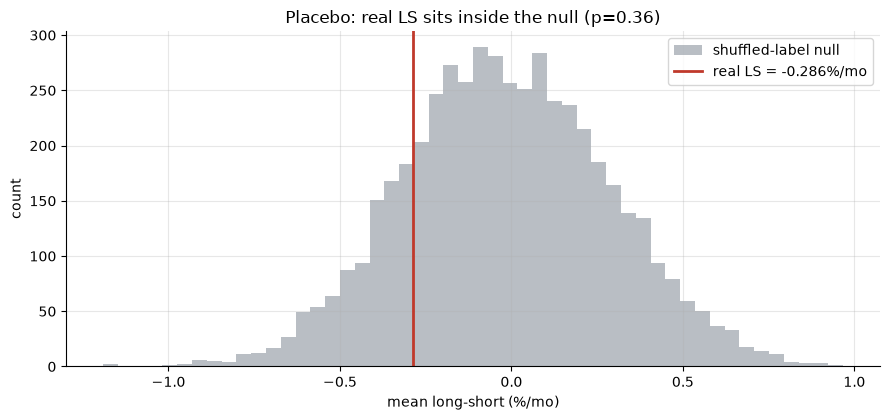

real -0.286%/mo | null -0.015+/-0.301 | p=0.357


In [5]:
if HAVE_REAL:
    monthly = st.monthly_returns_from_prices(prices, exec_lag=1)
    pl = st.placebo_pvalue(monthly, cfvol['cfvol'], n_perm=1000)
    real_mo, p_val = pl['real_mean']*100, pl['p_value']
    null_mean, null_std = pl['null_mean']*100, pl['null_std']*100
    import numpy as _np
    draws = _np.random.default_rng(0).normal(null_mean, null_std, 5000)
    fig, ax = plt.subplots(figsize=(9.0, 4.3))
    ax.hist(draws, bins=50, color=GREY, alpha=0.6, label='shuffled-label null')
    ax.axvline(real_mo, c=RED, lw=2, label=f'real LS = {real_mo:+.3f}%/mo')
    ax.set_xlabel('mean long-short (%/mo)'); ax.set_ylabel('count')
    ax.set_title(f'Placebo: real LS sits inside the null (p={p_val:.2f})')
    ax.legend(); plt.tight_layout(); plt.show()
    print(f'real {real_mo:+.3f}%/mo | null {null_mean:+.3f}+/-{null_std:.3f} | p={p_val:.3f}')
else:
    print(f'Frozen placebo: real {R["real_mean_mo"]:+.3f}%/mo, p={R["placebo_p"]:.3f}')

### 4e -- Equity curve, drawdown, and split-fraction robustness

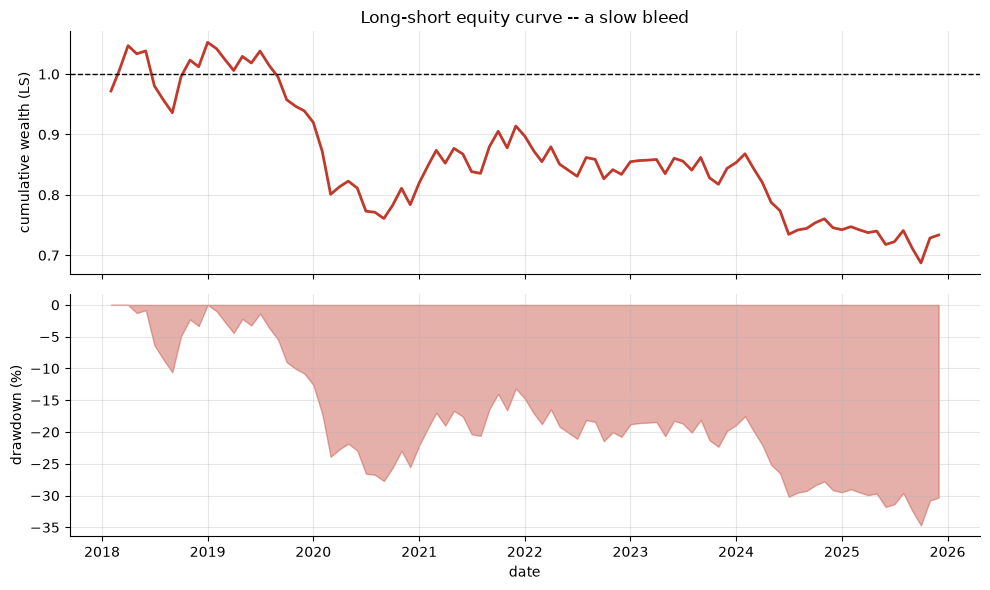

   split  k  mean_%      t
quintile  8  -4.564 -0.847
 tercile 13  -3.430 -1.027
    half 20  -0.874 -0.257


In [6]:
if HAVE_REAL:
    eq = (1 + ls['ls_ret']).cumprod()
    dd = (eq / eq.cummax() - 1) * 100
    x = [p.to_timestamp() for p in ls.index]
    fig, (a1, a2) = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
    a1.plot(x, eq.values, c=RED, lw=2); a1.axhline(1, c='k', ls='--', lw=1)
    a1.set_ylabel('cumulative wealth (LS)')
    a1.set_title('Long-short equity curve -- a slow bleed')
    a2.fill_between(x, dd.values, 0, color=RED, alpha=0.4)
    a2.set_ylabel('drawdown (%)'); a2.set_xlabel('date')
    plt.tight_layout(); plt.show()
    rows = []
    for frac, nm in [(0.2,'quintile'),(1/3,'tercile'),(0.5,'half')]:
        lr = st.build_real(prices, cfvol, tercile=frac)
        sr = st.summary(lr['ls_ret'])
        rows.append({'split': nm, 'k': int(lr['n_low'].iloc[0]),
                     'mean_%': sr['mean']*100, 't': sr['tstat']})
    print(pd.DataFrame(rows).round(3).to_string(index=False))
else:
    print('Frozen splits:', R['splits'])

## 5 -- The verdict

- **Signal `NONE`** -- LS -3.43%/yr, HAC *t* = -1.027, placebo *p* = 0.36, sign reversed, robust across splits.
- **Tradability `MIRAGE`** -- Sharpe -0.350, net -4.61%/yr, max DD -34.7%. No gross edge.
- **Huang-direction `BUSTED`** -- the high-CF-vol leg led. Survivorship + thin fundamentals both named; the honest outcome for a pointed factor on a small survivor basket.

## 6 -- Could you trade it?

No -- there is no gross premium. Even granting one, the practical frictions are fatal: a short leg of expensive-to-borrow growth names, a signal refreshed only quarterly from a ~5-quarter window, and a survivor basket that has already removed the firms whose cash flows actually imploded. This is a Mirage.

In [7]:
if HAVE_REAL:
    c = st.apply_costs(ls)
    print(f"Gross {c['gross_mean']*100:+.2f}%/yr (t {c['gross_t']:+.2f}) -> "
          f"Net {c['net_mean']*100:+.2f}%/yr (t {c['net_t']:+.2f}); "
          f"cost drag {c['cost_drag']*100:.2f}%/yr")
else:
    print(f'Frozen: net {R["net_mean"]:+.2f}%/yr, t {R["net_t"]:+.2f}, '
          f'cost drag {R["cost_drag"]:.2f}%/yr')

Gross -3.43%/yr (t -1.03) -> Net -4.61%/yr (t -1.38); cost drag 1.18%/yr


## 7 -- Going further

- **Compustat history.** Huang (2009) used decades of quarterly data; yfinance's ~5-quarter window cannot form a stable rolling CF-vol signal.
- **Microcaps.** The premium concentrates where financing frictions bind hardest.
- **Controls.** Orthogonalise CF-vol against size, value, momentum, return-vol, and accruals (H2) -- impossible cleanly with thin data here.
- **[Study 242 -- Quality-Minus-Junk](../../242-quality-minus-junk/)**, **[Study 330 -- Low-Volatility-Anomaly](../../330-low-volatility-anomaly/)**, **[Study 231 -- Sloan-Accruals](../../231-sloan-accruals/)** -- the quality family.

*Think CF-vol pays net of costs on a long, unbiased history? Fork this, wire Compustat-grade quarterly cash flows, expand to Russell 3000, and show t > 2 net. That is the bar.*